In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from scripts.preprocessing.pipeline import process

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import autocorrelation_plot

In [3]:
pd.set_option("display.float_format", "{:,.0f}".format)

In [4]:
train, (sample_submission, test), dqc_report = process(
    data_dir="../data", save_report_path="report.json"
)

Обнаружено 4023 записей с дублирующимися названиями после чистки!
Примеры дубликатов:
    item_id                      item_name
12       12  МИХЕЙ И ДЖУМАНДЖИ Сука любовь
30       30        007 КООРДИНАТЫ СКАЙФОЛЛ
31       31        007 КООРДИНАТЫ СКАЙФОЛЛ
32       32                             11
33       33                             11
35       35                  10 ЛЕТ СПУСТЯ
36       36                  10 ЛЕТ СПУСТЯ
37       37                  10 ЛЕТ СПУСТЯ
71       71            11 ДРУЗЕЙ ОУШЕНА WB
72       72            11 ДРУЗЕЙ ОУШЕНА WB

Найдено 1657 уникальных названий, которые повторяются:
                       item_name  count
0        007 КООРДИНАТЫ СКАЙФОЛЛ      2
1                  10 ЛЕТ СПУСТЯ      3
2                             11      2
3            11 ДРУЗЕЙ ОУШЕНА WB      2
4            12 ДРУЗЕЙ ОУШЕНА WB      2
5                 12 ЛЕТ РАБСТВА      2
6                      127 ЧАСОВ      3
7                   12ДВЕНАДЦАТЬ      2
8            13 ДРУЗЕЙ ОУ

In [5]:
train.describe()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id
count,2935821,"2,935,821","2,935,821","2,935,821","2,935,821","2,935,821","2,935,821"
mean,2014-04-03 05:44:57.946366208,15,33,"10,197",891,1,40
min,2013-01-01 00:00:00,0,0,0,0,0,0
25%,2013-08-01 00:00:00,7,22,"4,476",249,1,28
50%,2014-03-04 00:00:00,14,31,"9,343",399,1,40
75%,2014-12-05 00:00:00,23,47,"15,684",999,1,55
max,2015-10-31 00:00:00,33,59,"22,169","307,980","2,169",83
std,NaN,9,16,"6,324","1,730",3,17


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935821 entries, 0 to 2935820
Data columns (total 10 columns):
 #   Column              Dtype         
---  ------              -----         
 0   date                datetime64[ns]
 1   date_block_num      int64         
 2   shop_id             int64         
 3   item_id             int64         
 4   item_price          float64       
 5   item_cnt_day        float64       
 6   item_name           object        
 7   item_category_id    int64         
 8   item_category_name  object        
 9   shop_name           object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 224.0+ MB


# ==================================================================================================================================================================================================

# DATE AND DATE BLOCK NUM

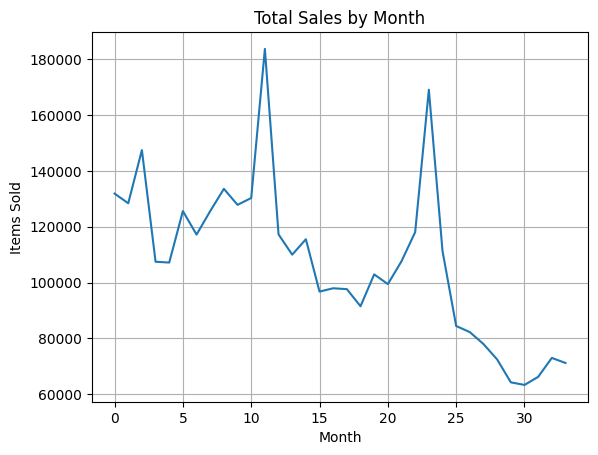

In [7]:
monthly_sales = train.groupby("date_block_num").item_cnt_day.sum()
plt.plot(monthly_sales)
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Items Sold")
plt.grid(True)
plt.show()

Пики на 11 и 23 месяцах — это декабрьский ажиотаж перед Новым годом. При этом общий тренд идет на спад.Для модели это значит, что месяц и общее падение спроса — самые важные фичи.

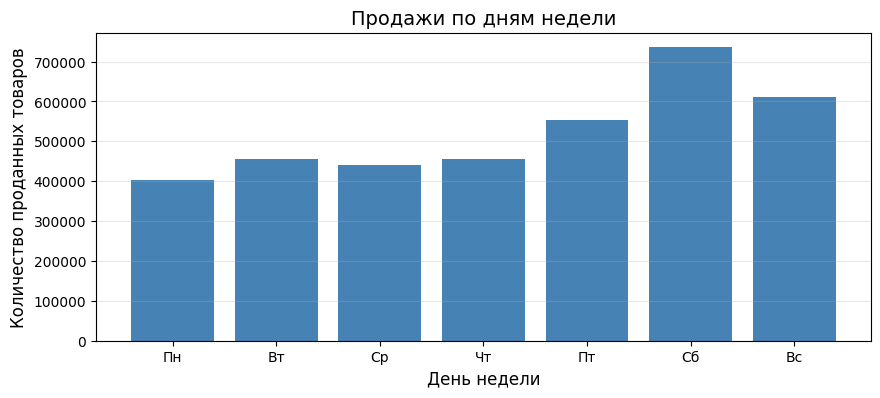

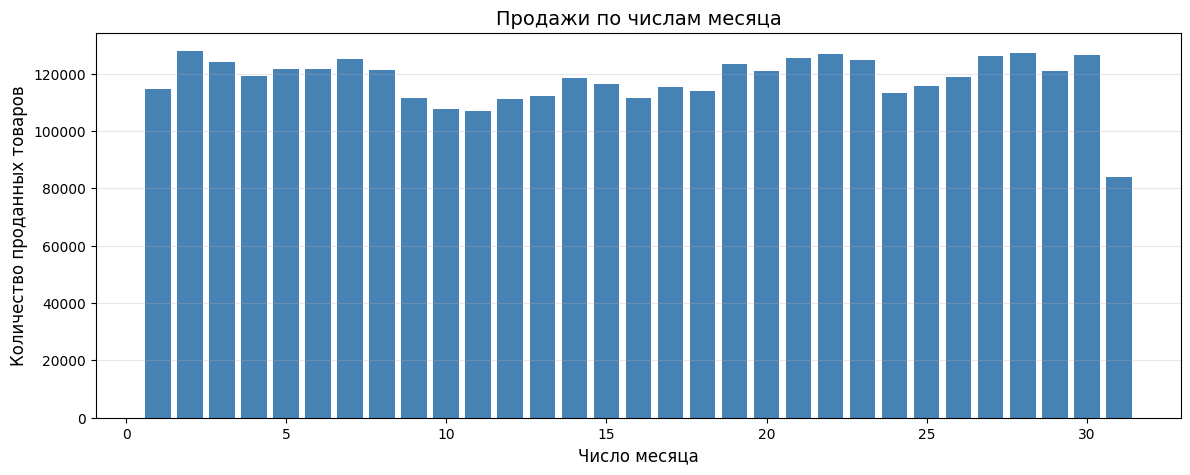

In [8]:
train["day_of_week"] = train["date"].dt.day_of_week
train["day_of_month"] = train["date"].dt.day

daily_sales = train.groupby(train.day_of_week)["item_cnt_day"].sum()
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

plt.figure(figsize=(10, 4))
plt.bar(days, daily_sales, color="steelblue")
plt.title("Продажи по дням недели", fontsize=14)
plt.xlabel("День недели", fontsize=12)
plt.ylabel("Количество проданных товаров", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

daily_of_month_sales = train.groupby("day_of_month")["item_cnt_day"].sum()

plt.figure(figsize=(14, 5))
plt.bar(daily_of_month_sales.index, daily_of_month_sales.values, color="steelblue")
plt.title("Продажи по числам месяца", fontsize=14)
plt.xlabel("Число месяца", fontsize=12)
plt.ylabel("Количество проданных товаров", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.show()

1. Самый популярный день недели: Сб
2. Самый непопулярный день недели: Пн
3. график продаж по дням в месяце довольно ровный, только немного идет спад в середине месяца и на последний день месяца

C:\Users\germa\AppData\Local\Temp\ipykernel_22692\786238927.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


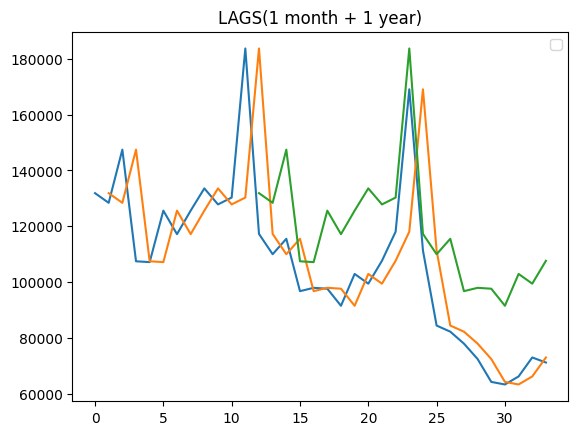

In [9]:
lag_month = monthly_sales.shift(1)
lag_year = monthly_sales.shift(12)

plt.plot(monthly_sales)
plt.plot(lag_month)
plt.plot(lag_year)
plt.legend()
plt.title("LAGS(1 month + 1 year)")
plt.show()

Тут видно, что лаг в 1 месяц (оранжевый) почти идеально повторяет график, но с задержкой. Лаг в 1 год (зеленый) ловит новогодние пики, подтверждая, что сезонность тут цикличная.

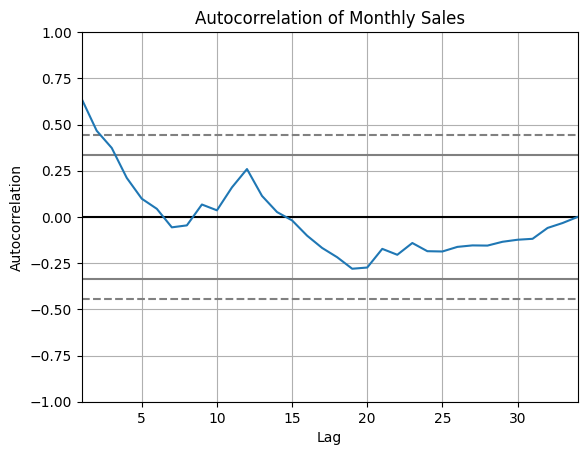

In [10]:
autocorrelation_plot(monthly_sales)
plt.title("Autocorrelation of Monthly Sales")
plt.show()

Автокорреляция подтверждает, что данные сильно зависят от прошлого. Высокое значение на первых лагах значит, что прошлый месяц хорошо предсказывает следующий, а скачок в районе 12 лага показывает годовую сезонность, что мы смотрели выше. То есть продажи сегодня это смесь того, что было месяц назад, и того, что было в это же время в прошлом году.

# ==================================================================================================================================================================================================

# SHOP ID AND SHOP NAME

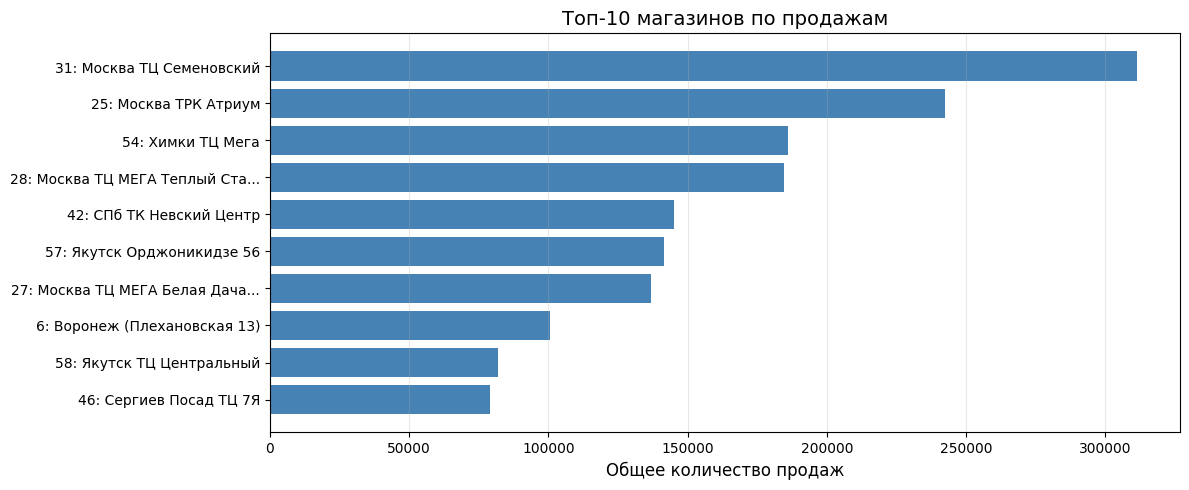


ТОП-5
  31: Москва ТЦ Семеновский — 311,230 продаж (г. Москва)
  25: Москва ТРК Атриум — 242,236 продаж (г. Москва)
  54: Химки ТЦ Мега — 186,148 продаж (г. Химки)
  28: Москва ТЦ МЕГА Теплый Стан II — 184,777 продаж (г. Москва)
  42: СПб ТК Невский Центр — 145,194 продаж (г. СПб)


In [11]:
shop_sales = (
    train.groupby(["shop_id", "shop_name"])["item_cnt_day"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

labels = [
    f"{sid}: {name[:25]}{'...' if len(name) > 25 else ''}"
    for sid, name in shop_sales.index
]

plt.figure(figsize=(12, 5))
plt.barh(range(len(shop_sales)), shop_sales.values, color="steelblue")
plt.yticks(range(len(shop_sales)), labels)
plt.xlabel("Общее количество продаж", fontsize=12)
plt.title("Топ-10 магазинов по продажам", fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nТОП-5")
for (sid, name), sales in shop_sales.head(5).items():
    city = name.split()[0] if name.split() else "Unknown"
    print(f"  {sid}: {name[:50]} — {sales:,.0f} продаж (г. {city})")

Тут сразу видно, что пара магазинов из Москвы явные лидеры.То есть продажи сильно зависят от конкретной точки, а не только от общей сезонности.А значит, что shop_id обязательная фича, потому что поведение у топовых ТЦ и маленьких точек будет абсолютно разным.

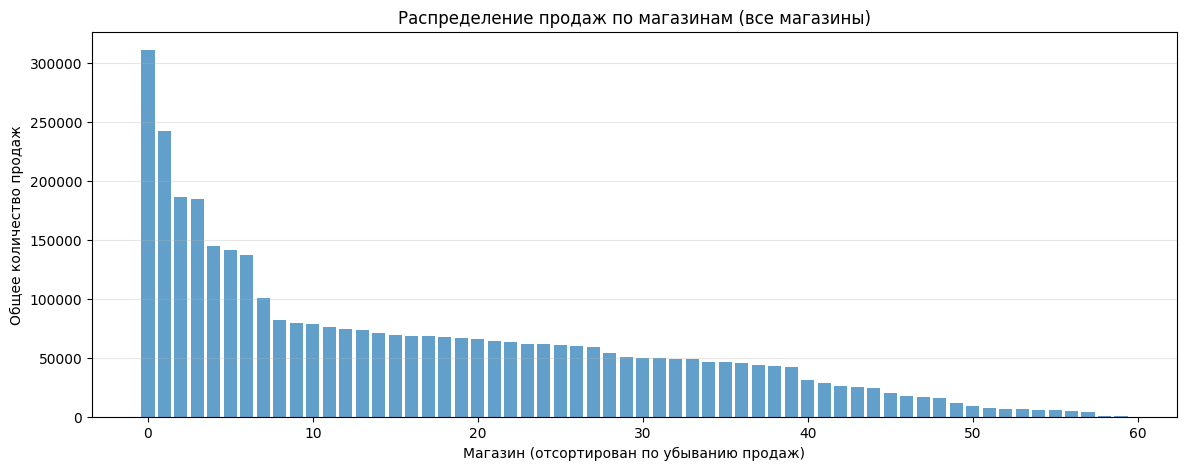

In [12]:
shop_sales_all = (
    train.groupby("shop_id")["item_cnt_day"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(14, 5))
plt.bar(range(len(shop_sales_all)), shop_sales_all.values, alpha=0.7)
plt.title("Распределение продаж по магазинам (все магазины)")
plt.xlabel("Магазин (отсортирован по убыванию продаж)")
plt.ylabel("Общее количество продаж")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [33]:
# shop_profile = train.groupby("shop_id").agg(
#     {
#         "item_cnt_day":"sum",
#         "item_price":"mean"
#     }
# )

# fig, ax1 = plt.subplots(figsize=(14, 6))

# color_sales = 'steelblue'
# ax1.set_xlabel('Shop ID', fontsize=12)
# ax1.set_ylabel('Total Sales (item_cnt_day)', color=color_sales, fontsize=12)
# ax1.bar(shop_profile.index, sorted(shop_profile['item_cnt_day'], reverse=True), color=color_sales, alpha=0.6, label='Sales')
# ax1.tick_params(axis='y', labelcolor=color_sales)
# ax1.grid(axis='y', linestyle='--', alpha=0.3)

# ax2 = ax1.twinx()
# color_price = 'crimson'
# ax2.set_ylabel('Average Price (item_price)', color=color_price, fontsize=12)
# ax2.plot(shop_profile.index, shop_profile['item_price'], color=color_price, marker='o', linewidth=2, label='Price')
# ax2.tick_params(axis='y', labelcolor=color_price)

# plt.title('Продажи vs Средняя цена по магазинам', fontsize=16, pad=20)
# plt.xticks(shop_profile.index)

# lines, labels = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# fig.tight_layout()
# plt.show()

Прямой связи выше цена - меньше продаж нет.Например, в магазине 31 гигантские продажи при средней цене, а в 12 цена зашкаливает, но спроса почти ноль.Это значит, что выручка зависит не от дешевизны, а от локации ТЦ или ассортимента.

C:\Users\germa\AppData\Local\Temp\ipykernel_22692\1413463616.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


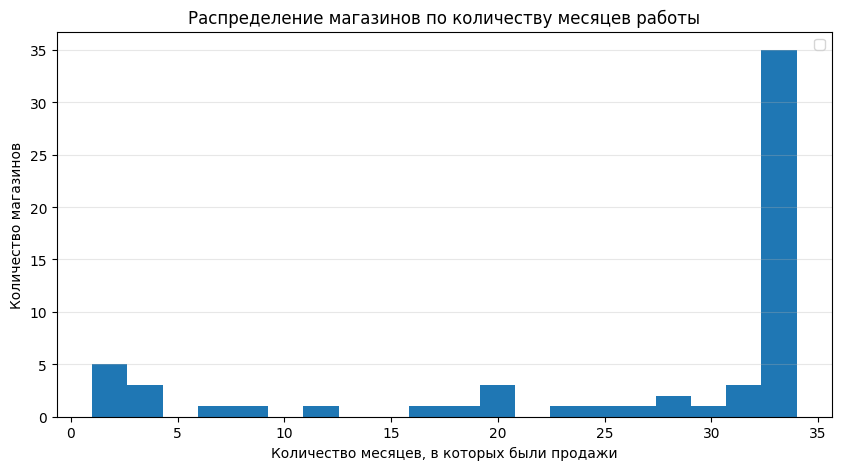


=== LIFECYCLE МАГАЗИНОВ ===
  Магазинов, работавших весь период (33 месяца): 3
  Магазинов, работавших < 6 месяцев: 8
  Медианный lifecycle: 34 месяцев


In [14]:
shop_life = train.groupby("shop_id")["date_block_num"].nunique()
plt.figure(figsize=(10, 5))
plt.hist(shop_life, bins=20)
plt.title("Распределение магазинов по количеству месяцев работы")
plt.xlabel("Количество месяцев, в которых были продажи")
plt.ylabel("Количество магазинов")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

shop_life = train.groupby("shop_id")["date_block_num"].nunique()
print("\n=== LIFECYCLE МАГАЗИНОВ ===")
print(f"  Магазинов, работавших весь период (33 месяца): {(shop_life == 33).sum()}")
print(f"  Магазинов, работавших < 6 месяцев: {(shop_life < 6).sum()}")
print(f"  Медианный lifecycle: {shop_life.median():.0f} месяцев")

1. Сильная неравномерность: топ-5 магазинов дают треть всех продаж
2. Магазины с аномально высокими ценами (2 9, 12, 20 и др.) имеют довольно низкие продажи
3. Нет прямой корреляции 'выше цена → меньше продаж' (см. scatter plot)
4. Большинство магазинов работают на протяжении всего периода (lifecycle высокий)

=== ФИЧА-ИНЖИНИРИНГА ===
  - Сделать target encoding для shop_id (средние продажи магазина)
  - Создать признак 'is_top_shop' для топ-5/10 магазинов
  - Добавить среднюю цену по магазину как признак
  - Учесть lifecycle магазина (количество активных месяцев)


# ==================================================================================================================================================================================================

# ITEM ID AND ITEM NAME

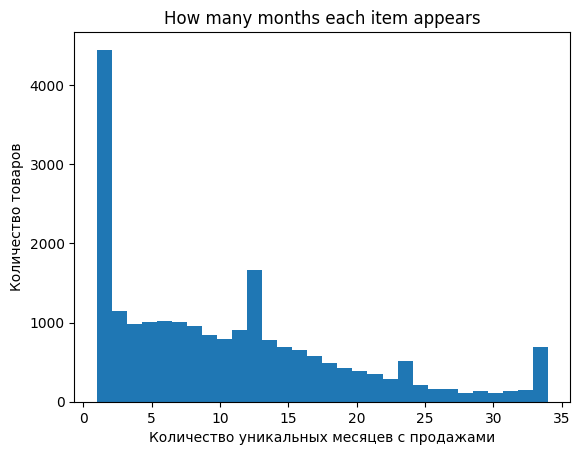

In [15]:
items_frequency = train.groupby("item_id").date_block_num.nunique()
plt.hist(items_frequency, bins=30)
plt.title("How many months each item appears")
plt.xlabel("Количество уникальных месяцев с продажами")
plt.ylabel("Количество товаров")
plt.show()

In [16]:
cold_items = (items_frequency == 1).sum()
cold_items_percent = cold_items / len(items_frequency) * 100
print(
    f"  Товаров, продававшихся только 1 месяц: {cold_items} ({cold_items_percent:.1f}%)"
)
print(
    "  Для таких товаров нельзя использовать собственные лаги → нужны category-level признаки"
)

  Товаров, продававшихся только 1 месяц: 2999 (13.8%)
  Для таких товаров нельзя использовать собственные лаги → нужны category-level признаки


Этот график показывает жизненный цикл товара. Видно по огромному бину слева, что большинство товаров появляются в продаже всего на пару месяцев и больше не возвращаются. То есть у большинства позиций нет долгой истории, поэтому одних только лагов будет недостаточно, придется опираться на признаки категорий, чтобы предсказывать данные товары.


# ==================================================================================================================================================================================================

# ITEM CATEGORY ID AND ITEM CATEGORY NAME

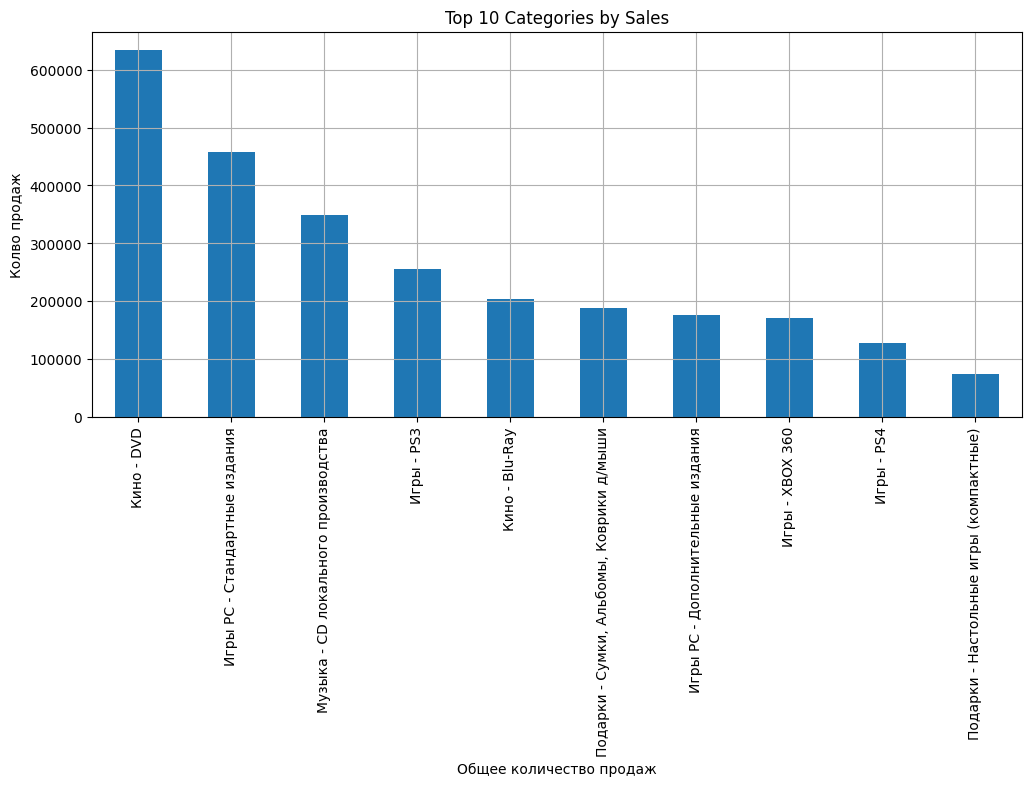

In [17]:
cat_sales = (
    train.groupby("item_category_name")
    .item_cnt_day.sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
cat_sales.plot(kind="bar")
plt.title("Top 10 Categories by Sales")
plt.xlabel("Общее количество продаж")
plt.ylabel("Колво продаж")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Абсолюьтными лидерами по датасету являются аксессуары для PS4 и Xbox 360, то есть остальные вещи продаются единциами.


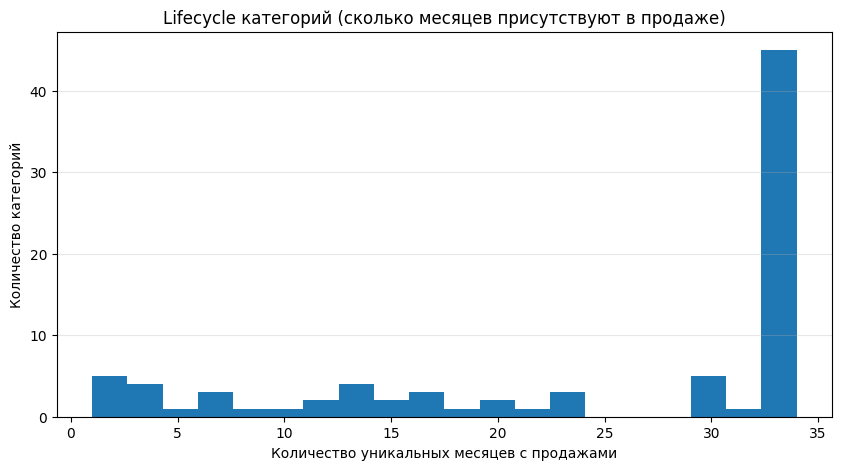


=== LIFECYCLE КАТЕГОРИЙ ===
  Категорий, присутствовавших весь период: 0
  Категорий, присутствовавших < 6 месяцев: 10


In [18]:
# Lifecycle категорий
cat_life = train.groupby("item_category_id")["date_block_num"].nunique()
plt.figure(figsize=(10, 5))
plt.hist(cat_life, bins=20)
plt.title("Lifecycle категорий (сколько месяцев присутствуют в продаже)")
plt.xlabel("Количество уникальных месяцев с продажами")
plt.ylabel("Количество категорий")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("\n=== LIFECYCLE КАТЕГОРИЙ ===")
print(f"  Категорий, присутствовавших весь период: {(cat_life == 33).sum()}")
print(f"  Категорий, присутствовавших < 6 месяцев: {(cat_life < 6).sum()}")

# ==================================================================================================================================================================================================

# ITEM PRICE

### Тут подвыборка, поэтому чутка поменялись выбросы

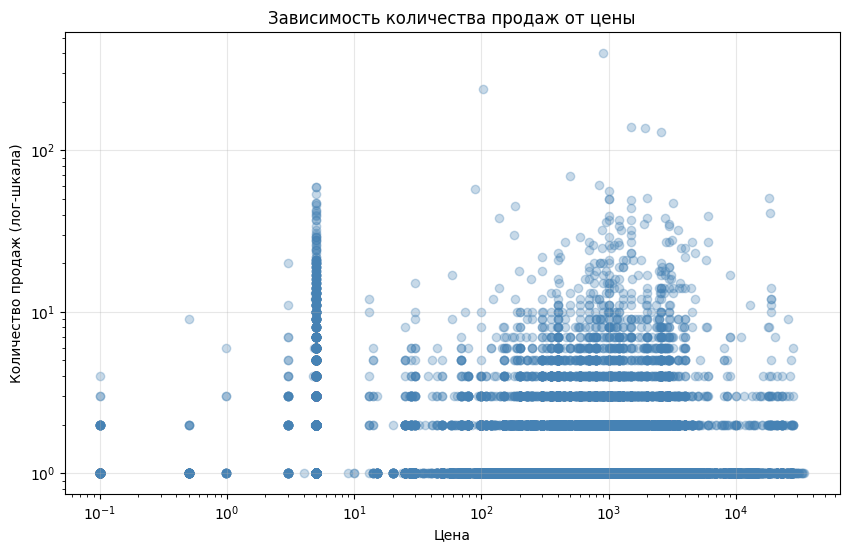

In [10]:
sample = train.sample(min(100000, len(train)))
plt.figure(figsize=(10, 6))
plt.scatter(sample["item_price"], sample["item_cnt_day"], alpha=0.3, c="steelblue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Цена")
plt.ylabel("Количество продаж (лог-шкала)")
plt.title("Зависимость количества продаж от цены")
plt.grid(True, alpha=0.3)
plt.show()

Основная масса продаж это дешёвые товары, но есть выбросы по цене (топ 10 нижу). Они не являются ошибками и будут оставлены без изменений (после топ 10 обоснование)

### Выбросы по цене

In [11]:
price_99 = train["item_price"].quantile(0.99)
price_outliers = train[train["item_price"] > price_99]
print(f"  99-й перцентиль цены: {price_99:.2f} ₽")
print(
    f"  Количество записей с ценой выше 99-го перцентиля: {len(price_outliers)} ({len(price_outliers) / len(train) * 100:.2f}%)\n"
)

print("Выбросы по цене")
high_price_items = (
    price_outliers.groupby(["item_id", "item_name"])
    .agg(
        count=("item_price", "count"),
        avg_price=("item_price", "mean"),
        total_sales=("item_cnt_day", "sum"),
    )
    .sort_values("avg_price", ascending=False)
    .head(10)
)

for (item_id, item_name), row in high_price_items.iterrows():
    name_short = item_name[:40] if len(item_name) > 40 else item_name
    print(
        f"  {item_id}: {name_short} — цена: {row['avg_price']:,.0f}, продано: {row['total_sales']:.0f} шт."
    )

  99-й перцентиль цены: 5999.00 ₽
  Количество записей с ценой выше 99-го перцентиля: 28714 (0.98%)

Выбросы по цене
  6066: Radmin 3 - 522 лиц. — цена: 307,980, продано: 1 шт.
  13199: Коллекционные шахматы — цена: 50,999, продано: 1 шт.
  7241: UserGate Proxy Firewall 6.X с модулем фи — цена: 49,782, продано: 1 шт.
  7238: UserGate Proxy Firewall 6.X до 100 сесси — цена: 42,000, продано: 1 шт.
  14173: Лицензия 1С-Битрикс Управление сайтом -  — цена: 40,900, продано: 1 шт.
  13403: Комплект Microsoft Xbox One 1TB Limited  — цена: 39,990, продано: 13 шт.
  5748: Photoshop 13 Windows Russian BOX — цена: 35,133, продано: 7 шт.
  13503: Комплект Sony PlayStation 4Blackигра Ass — цена: 34,990, продано: 3 шт.
  13448: Комплект Sony PlayStation 4Blackигра Unc — цена: 34,823, продано: 9 шт.
  2410: CorelDRAW Graphics Suite X6 - Small Busi — цена: 34,714, продано: 2 шт.


### Решение по выбросам (>99-го перцентиля)

Выбросы оставлены (не удалены и не обрезаны).

Почему:
- Это реальные товары (лицензии ПО, игровые консоли, коллекционные издания), а не ошибки данных.
- Могут быть важны для прогноза (сезонный рост продаж дорогих товаров).
- Количество записей <1% — влияние на обучение минимально.
- Деревья (LightGBM) устойчивы к выбросам.(почему используем дерево смотреть ниже на матрице корреляций)

Что делаем на этапе моделирования:
- `log1p`-трансформация цены для сжатия масштаба.
- Бинарный признак `is_expensive` (если нужно).

### Выбросы по количеству

In [12]:
cnt_99 = train["item_cnt_day"].quantile(0.99)
cnt_outliers = train[train["item_cnt_day"] > cnt_99]
print(f"Порог (99-й перцентиль): {cnt_99:.2f}")
print(
    f"Количество записей-выбросов: {len(cnt_outliers)} ({len(cnt_outliers) / len(train) * 100:.2f}%)\n"
)

top_cnt = cnt_outliers.nlargest(5, "item_cnt_day")
print("Топ 5 выбросов по количеству):")
display(
    top_cnt[["item_id", "item_name", "item_cnt_day", "date", "shop_id", "shop_name"]]
)

if len(cnt_outliers) > 0:
    max_record = cnt_outliers.loc[cnt_outliers["item_cnt_day"].idxmax()]
    print("\nИнфа по топ 1 выбросу")
    print(f"Дата: {max_record['date']}")
    print(f"Товар: {max_record['item_name']} (ID: {max_record['item_id']})")
    print(f"Продано: {max_record['item_cnt_day']:.0f} шт.")
    print(f"Магазин: {max_record['shop_name']} (ID: {max_record['shop_id']})")
    print(f"Цена за единицу: {max_record['item_price']:.2f}")
    print(f"Выручка: {max_record['item_price'] * max_record['item_cnt_day']:,.0f}")

Порог (99-й перцентиль): 5.00
Количество записей-выбросов: 27411 (0.93%)

Топ 5 выбросов по количеству):


,item_id,item_name,item_cnt_day,date,shop_id,shop_name
2928842,11373,Доставка до пункта выдачи,"2,169",2015-10-28,12,Интернет-магазин ЧС
2371876,20949,Фирменный пакет майка 1С Интерес белый45 мкм,"1,000",2015-01-15,12,Интернет-магазин ЧС
2881246,9248,Билет ИгроМир 2015 - 3 октября 2015Цифровая ве...,669,2015-09-30,12,Интернет-магазин ЧС
2882156,9249,Билет ИгроМир 2015 - 3 октября 2015УПР Цифрова...,637,2015-09-30,55,Цифровой склад 1С-Онлайн
2578666,3731,Grand Theft Auto V PC русские субтитры,624,2015-04-14,12,Интернет-магазин ЧС



Инфа по топ 1 выбросу
Дата: 2015-10-28 00:00:00
Товар: Доставка до пункта выдачи (ID: 11373)
Продано: 2169 шт.
Магазин: Интернет-магазин ЧС (ID: 12)
Цена за единицу: 0.91
Выручка: 1,971


### Вывод по выбросам количества (>99-го перцентиля, порог 5 шт./день)

**Экстремальные значения** (до 2 169 шт./день) приходятся не на обычные товары, а на:
   - **Услуги** («Доставка до пункта выдачи» с ценой 0,91) — 2 169 единиц
   - **Упаковку / фирменную продукцию** («Фирменный пакет») — 1 000 единиц
   - **Билеты на мероприятия** (ИгроМир 2015) — 600-700 единиц
   - **Цифровые товары / ключи** (GTA V) — 624 единиц

Все рекордные продажи (кроме одного) приходятся на **магазин №12** («Интернет-магазин ЧС»).
Цены на эти позиции часто минимальны, или же это какие-то лимитированные события как билет Билет ИгроМир 2015, что объясняет высокий объём при низкой выручке.

С точки зрения модели:
   - Эти записи **не являются ошибками данных** — это реальные транзакции (услуги, билеты, упаковка).
   - Их вклад в целевую переменную `item_cnt_day` может быть обоснованно большим.
   - Деревья устойчивы к таким выбросам, поэтому **оставляем их без изменений**.

Как действовать:
   - Создать бинарный признак `is_service_or_ticket`, чтобы модель могла отдельно учитывать такие нестандартные позиции.
   - Или оставить как есть — деревья сами найдут паттерны.


=== ТОВАРЫ С ПРОДАЖАМИ > 20 ЕДИНИЦ/ДЕНЬ ===
        item_id                                          item_name  \
1116      13598           Крафт пакет Интересные подарки-оранжевый   
5433      13598           Крафт пакет Интересные подарки-оранжевый   
6239      13598           Крафт пакет Интересные подарки-оранжевый   
48453      2808                 Diablo III PC Jewel русская версия   
52577      2808                 Diablo III PC Jewel русская версия   
53082     14824          МТГБазовый Выпуск 2012 Бустер арт. 589950   
80453     20384  Фигурка Assassins Creed III Connor The Hunter ...   
111166     3186     Elder Scrolls V Skyrim PC Jewel русская версия   
111176     6736  Star Wars the Old Republic. Карта оплаты игров...   
131016     2749   Dead Space 3 Limited Edition PC русские субтитры   

        item_cnt_day  date_block_num  
1116              26               0  
5433              64               0  
6239              29               0  
48453             22        

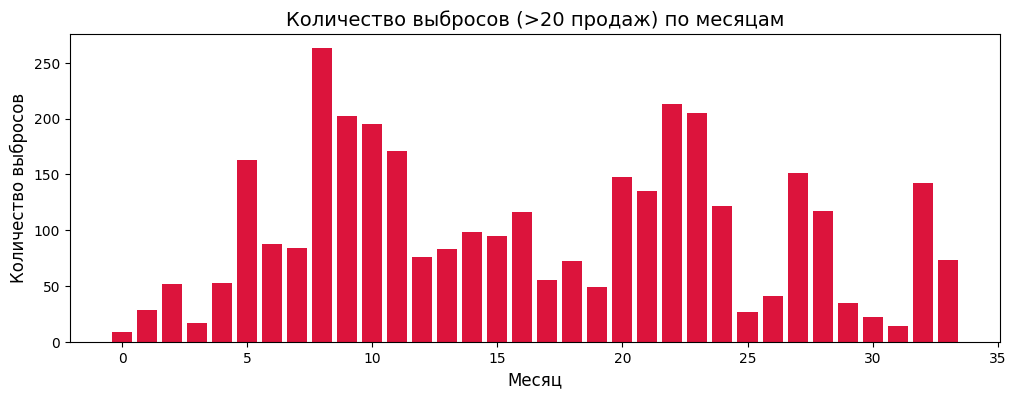

In [22]:
high_outliers = train[train["item_cnt_day"] > 20]
print("\n=== ТОВАРЫ С ПРОДАЖАМИ > 20 ЕДИНИЦ/ДЕНЬ ===")
print(
    high_outliers[["item_id", "item_name", "item_cnt_day", "date_block_num"]].head(10)
)

high_outliers_by_month = high_outliers.groupby("date_block_num").size()
plt.figure(figsize=(12, 4))
plt.bar(high_outliers_by_month.index, high_outliers_by_month.values, color="crimson")
plt.title("Количество выбросов (>20 продаж) по месяцам", fontsize=14)
plt.xlabel("Месяц", fontsize=12)
plt.ylabel("Количество выбросов", fontsize=12)
plt.show()

1. Основная масса товаров — в диапазоне до 5,000 (дешёвые игры, аксессуары)
2. Есть длинный хвост дорогих товаров (техника, коллекционные издания)
3. Корреляция цена-продажи слабая и разнонаправленная по категориям
4. Выбросы (>99%) — это единичные дорогие товары с низкими продажами

=== ФИЧА-ИНЖИНИРИНГА ===
  - Использовать log1p трансформацию для цены (нормализация)
  - Создать бинарный признак 'is_expensive' (>99-го перцентиля)
  - Добавить 'price_rank_in_category' (ранг цены внутри категории)
  - Для модели: попробовать как raw price, так и log(price)

# ==================================================================================================================================================================================================

# ITEM COUNT DAY

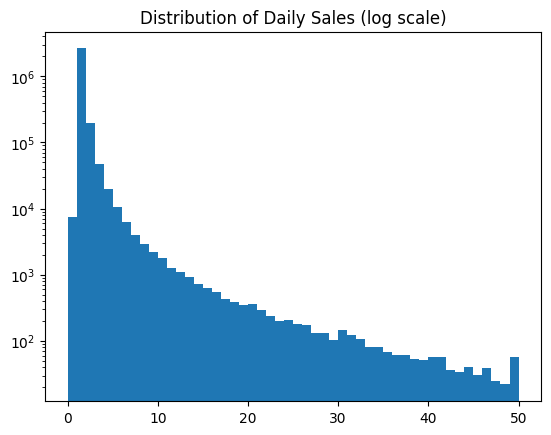

In [23]:
plt.hist(train["item_cnt_day"], bins=50, range=(0, 50))
plt.yscale("log")
plt.title("Distribution of Daily Sales (log scale)")
plt.show()

Логарифмическая шкала показывает, что почти все продажи это штучный товар (1–2 единицы). Редкие выбросы (>20) это оптовые закупки ну или перед праздниками. Они остаются в данных без изменений, так как деревья устойчивы к выбросам.

# ==================================================================================================================================================================================================

# OTHER USEFUL

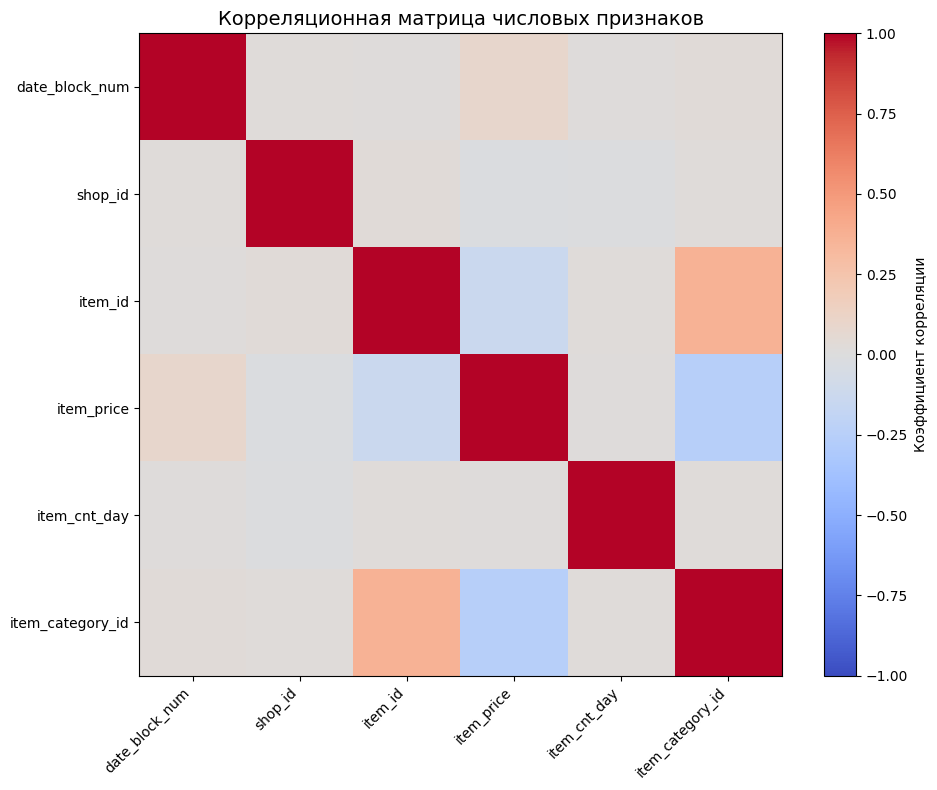

In [24]:
numeric_cols = [
    "date_block_num",
    "shop_id",
    "item_id",
    "item_price",
    "item_cnt_day",
    "item_category_id",
]

corr_sample = train[numeric_cols].sample(100000)

corr_matrix = corr_sample.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Коэффициент корреляции")
plt.xticks(
    range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right"
)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Корреляционная матрица числовых признаков", fontsize=14)
plt.tight_layout()
plt.show()

### Корреляционный анализ

Анализ корреляции числовых признаков показал:

1. **Ожидаемые связи:**
   - `item_id` и `item_category_id` (r = 0.5): товары одной категории имеют близкие ID.
   - `item_price` и `item_category_id` (r = -0.5): некоторые категории стабильно дешевле других.

2. **Связь с целевой переменной (`item_cnt_day`) практически отсутствует** (все |r| < 0.05), а значит данные разряженные, где большинство значений нули.

3. **Отсутствие мультиколлинеарности** - это классно.

4. **Линейные корреляции не отражают реальной важности признаков** для прогнозирования продаж. Основные зависимости носят нелинейный характер и будут выявлены деревьями.

**Вывод:** линейные методы неэффективны; необходим переход к градиентному бустингу на деревьях.

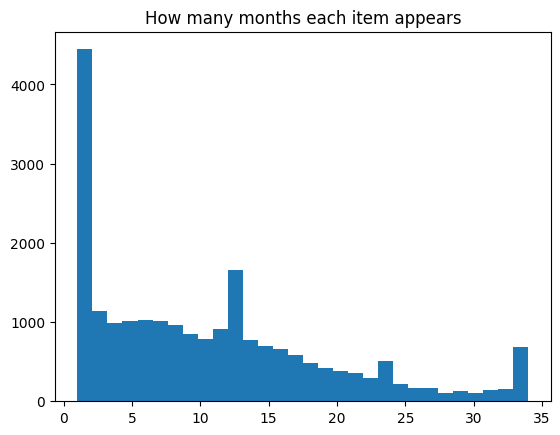

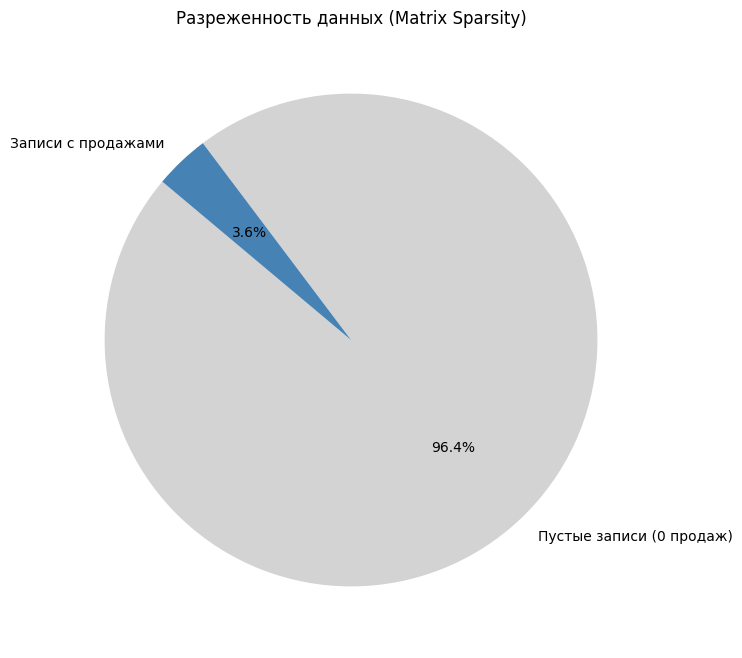

Всего возможных комбинаций: 44486280
Реальных фактов продаж: 1609124


In [16]:
items_frequency = train.groupby("item_id").date_block_num.nunique()
plt.hist(items_frequency, bins=30)
plt.title("How many months each item appears")
plt.show()

n_shops = train["shop_id"].nunique()
n_items = train["item_id"].nunique()
n_months = train["date_block_num"].nunique()

total_combinations = n_shops * n_items * n_months
actual_sales = train.groupby(["date_block_num", "shop_id", "item_id"]).size().shape[0]

labels = ["Пустые записи (0 продаж)", "Записи с продажами"]
sizes = [total_combinations - actual_sales, actual_sales]

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["lightgray", "steelblue"],
)
plt.title("Разреженность данных (Matrix Sparsity)")
plt.show()

print(f"Всего возможных комбинаций: {total_combinations}")
print(f"Реальных фактов продаж: {actual_sales}")

Видно только 3.6% реальных фактов продаж(а нам было бы идеально иметь декартово произведение между товарами и магазинами). Если мы будем учить модель только на этих данных, она станет будет думать, что нулей никогда нет и никогда не научится предсказывать отсутствие спроса.


# ==================================================================================================================================================================================================

## ИТОГИ EDA

### 1. Качество данных
- Данные чистые: нет пропусков, дубликаты обработаны
- 96.4% возможных комбинаций (shop, item, month) — нулевые продажи
- → Нужна модель, умеющая работать с разреженными данными (LightGBM, CatBoost)

### 2. Аномалии
- 1 запись с отрицательной ценой → заменена на медиану
- Ценовые выбросы (>99%) оставлены (могут быть коллекционными)
- Количественные выбросы (>20) — декабрьские пики

### 3. Рекомендации по ETL (выполненные действия)

| Проблема | Обработка | Обоснование |
|----------|-----------|--------------|
| Отрицательные цены | Замена на медиану товара (или глобальную) | Возвраты или ошибки ввода |
| Отрицательное количество | Clip(lower=0) | Нельзя продать отрицательное число |
| Полные дубликаты строк | Удаление (drop_duplicates) | Сбой при записи данных |
| Дубликаты по ключу (date, shop_id, item_id) | Агрегация (суммировать количество, взять первую цену) | Один чек могли пробить несколько раз |
| Ценовые выбросы (>99%) | **Оставлены** | Реальные дорогие товары (лицензии, консоли) |
| Количественные выбросы (>20) | **Оставлены** | Оптовые закупки, декабрьские пики |
| Пропуски в названиях | Замена на UNKNOWN | Целостность данных |
| Дубликаты названий после чистки | **Не удаляются** (только диагностика) | Разные товары могут иметь одинаковое очищенное имя |

### 4. Feature Engineering

| Категория | Признак | Описание |
|-----------|---------|-----------|
| **Временные** | `lag_1`, `lag_12` | Продажи за предыдущий месяц и за месяц год назад |
| | `rolling_mean_3` | Скользящее среднее за 3 месяца |
| | `day_of_week_onehot` | One-hot кодирование дня недели |
| **Магазины** | `shop_target_encoding` | Средние продажи магазина за всю историю (или скользящее среднее) |
| | `is_top_shop` | Бинарный признак для топ-5/10 магазинов |
| | `shop_avg_price` | Средняя цена товара в магазине |
| | `shop_lifecycle` | Количество месяцев, в которых магазин имел продажи |
| **Товары** | `item_category_target_encoding` | Средние продажи категории |
| | `is_cold_item` | Бинарный признак для товаров, которые продавались только 1 месяц |
| **Цена** | `log_price` | Логарифм цены (log1p) для сжатия масштаба |
| | `is_expensive` | Бинарный признак: цена > 99-го перцентиля |
| | `price_rank_in_category` | Ранг цены товара внутри своей категории |
| **Разреженность** | `sales_last_month` | Были ли продажи в предыдущем месяце (бинарный) |
| **Цена / тип** | `is_service_or_ticket` | Бинарный признак: товар является услугой, билетом или упаковкой (по ключевым словам) |